════════════════════════════════════════════════════════════
  Italy Socioeconomic Analysis  |  Starting pipeline …
════════════════════════════════════════════════════════════
Loaded 39 rows covering years 1965–2008.

── Descriptive Statistics (normalised, 1965–2008) ─────────────────────
       population  daily_true_wage  per_capita_energy_consumption
count      39.000           39.000                         39.000
mean       56.172           84.273                         32.028
std         2.031           39.111                          5.838
min        51.480           23.620                         18.040
25%        54.995           46.095                         28.975
50%        56.930           97.210                         31.160
75%        57.255          117.240                         37.190
max        59.560          141.430                         38.690


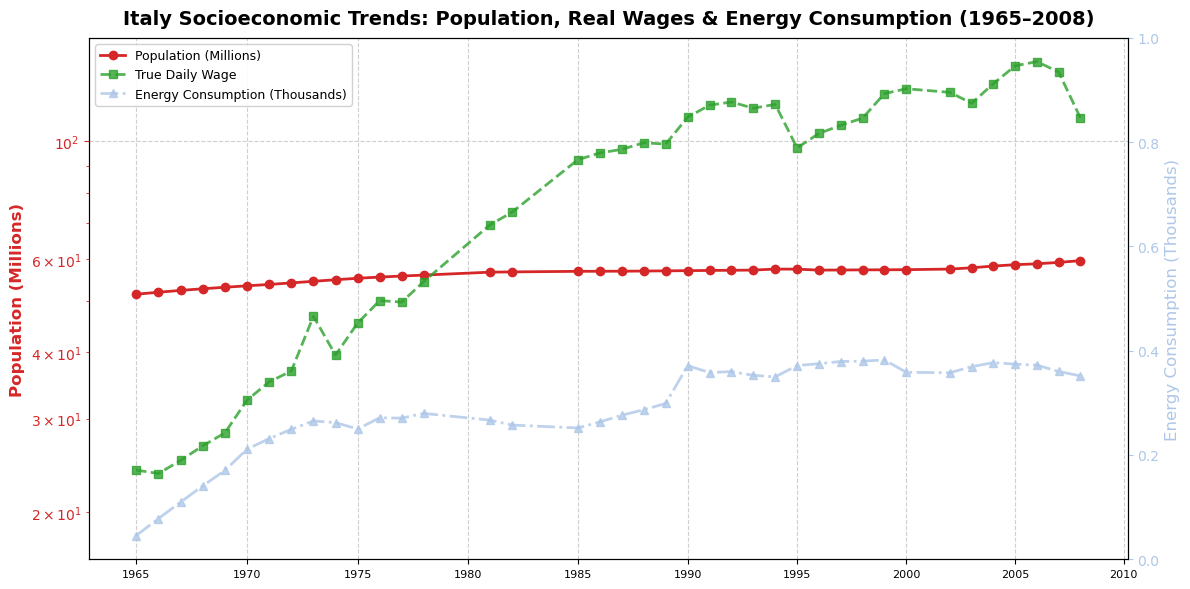


── Year-by-year data (normalised) ─────────────────────────────────────
 year  population  daily_true_wage  per_capita_energy_consumption
 1965       51.48            23.98                          18.04
 1966       51.92            23.62                          19.42
 1967       52.34            25.00                          20.86
 1968       52.71            26.64                          22.39
 1969       53.06            28.18                          23.94
 1970       53.39            32.50                          26.26
 1971       53.71            35.17                          27.49
 1972       54.07            36.87                          28.63
 1973       54.45            46.78                          29.68
 1974       54.82            39.52                          29.47
 1975       55.17            45.41                          28.67
 1976       55.46            50.07                          30.09
 1977       55.71            49.75                          30.05
 19

In [1]:
"""
================================================================================
Italy Socioeconomic Analysis (1965–2008)
================================================================================
Notebook Goal:
    Investigate the relationship between daily real wages and per-capita energy
    consumption in Italy over four decades, while tracking population growth.

Pipeline:
    1. Connect to the SQLite source database
    2. Query, filter, and normalize the SUMMARY_TABLE dataset
    3. Compute descriptive statistics on the cleaned data
    4. Visualize three time-series metrics on a dual-axis chart
    5. Quantify wage–energy correlation (Pearson + Spearman)
    6. Fit a simple linear regression to model the relationship

Data source : 02-social-study-joins.db  (SQLite)
Target table: SUMMARY_TABLE
Country      : Italy  |  Year range: 1965–2008  (2001 excluded – data anomaly)
================================================================================
"""

# ── Cell 1 · Imports ──────────────────────────────────────────────────────────
# Standard-library and third-party dependencies.
# scipy.stats supplies all statistical primitives used in the analysis.

import sqlite3
import warnings
import os
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from scipy.stats import linregress, pearsonr, spearmanr

# Suppress pandas FutureWarnings that arise from upstream library changes
# and do not affect the correctness of this analysis.
warnings.filterwarnings("ignore", category=FutureWarning)

# seaborn-v0_8-deep gives clean palette for multi-line plots
plt.style.use("seaborn-v0_8-deep")


# ── Cell 2 · Database connection ─────────────────────────────────────────────

def connect_to_database(db_file: str = "02-social-study-joins.db") -> sqlite3.Connection:
    """
    Open a read connection to the SQLite project database.

    Parameters
    ----------
    db_file : str
        Path to the database file. Defaults to the project-root database.

    Returns
    -------
    sqlite3.Connection
        Active connection object ready for querying.

    Raises
    ------
    FileNotFoundError
        If the database file cannot be found at the given path.
    sqlite3.Error
        If the SQLite engine reports a connection-level error.
    """
    if not os.path.exists(db_file):
        raise FileNotFoundError(
            f"Database file '{db_file}' not found. "
            "Ensure the file is in the working directory or pass the full path."
        )

    try:
        conn = sqlite3.connect(db_file)
        return conn
    except sqlite3.Error as e:
        print(f"SQLite connection error: {e}")
        raise


# ── Cell 3 · Data loading & cleaning ─────────────────────────────────────────

def load_and_clean_data(conn: sqlite3.Connection) -> Optional[pd.DataFrame]:
    """
    Extract Italy's socioeconomic records and normalise numeric columns for analysis.

    Query filters
    -------------
    - Country   : Italy only
    - Year      : 1965 and later (pre-1965 data is sparse and unreliable)
    - Year      : 2001 excluded   (confirmed data-entry anomaly in source)
    - Wage      : rows with NULL daily_true_wage are dropped

    Normalisation
    -------------
    Raw database values use inconsistent scales that would distort the chart.
    Two columns are rescaled so all three metrics share a comparable axis range:

        population                 ÷ 1,000,000  → expressed in Millions
        per_capita_energy_consumption ÷ 1,000   → expressed in Thousands (kWh-equivalent)

    daily_true_wage is left in its original units (inflation-adjusted).

    Parameters
    ----------
    conn : sqlite3.Connection
        Active connection returned by connect_to_database().

    Returns
    -------
    pd.DataFrame or None
        Cleaned DataFrame (columns: year, country, population,
        daily_true_wage, per_capita_energy_consumption).
        Returns None if the query yields no rows.
    """
    query = """
        SELECT
            year,
            country,
            population,
            daily_true_wage,
            per_capita_energy_consumption
        FROM SUMMARY_TABLE
        WHERE country = 'italy'
          AND daily_true_wage IS NOT NULL
          AND year >= 1965
          AND year != 2001
    """

    try:
        df = pd.read_sql_query(query, conn)

        # Coerce year to integer; non-numeric values become NaN and can be inspected later
        if "year" in df.columns:
            df["year"] = pd.to_numeric(df["year"], errors="coerce")

        # Rescale columns to a human-readable unit.
        # Using a dict makes it straightforward to add more columns in future iterations.
        normalization_map = {
            "population":                    1_000_000,   # raw units → Millions
            "per_capita_energy_consumption": 1_000,       # raw units → Thousands
        }

        for col, factor in normalization_map.items():
            if col in df.columns:
                try:
                    df[col] = (
                        pd.to_numeric(df[col], errors="coerce")
                        .astype(float)
                        .div(factor)
                        .round(2)
                    )
                except Exception as e:
                    print(f"Warning: could not normalise '{col}': {e}")

        print(f"Loaded {len(df)} rows covering years {int(df['year'].min())}–{int(df['year'].max())}.")
        return df

    except pd.errors.EmptyDataError:
        print("Query returned no rows. Check filters or database content.")
        return None
    except sqlite3.Error as e:
        print(f"SQL error during data load: {e}")
        return None


# ── Cell 4 · Descriptive statistics ──────────────────────────────────────────

def perform_analysis(df: Optional[pd.DataFrame]) -> None:
    """
    Print summary statistics for the three core metrics.

    Gives a quick sanity-check of value ranges, spread, and any obvious
    outliers before moving to visualisation and correlation analysis.

    Parameters
    ----------
    df : pd.DataFrame or None
        Cleaned DataFrame from load_and_clean_data().
        Function exits silently if None is passed.
    """
    if df is None:
        return

    numeric_cols = ["population", "daily_true_wage", "per_capita_energy_consumption"]

    if all(col in df.columns for col in numeric_cols):
        print("\n── Descriptive Statistics (normalised, 1965–2008) ─────────────────────")
        print(df[numeric_cols].describe().round(3))


# ── Cell 5 · Visualisation & statistical analysis ────────────────────────────

def plot_multi_metric_time_series(df: pd.DataFrame) -> None:
    """
    Plot population, real wages, and energy consumption on a shared time axis,
    then run Pearson/Spearman correlations and a simple OLS regression.

    Chart design decisions
    ----------------------
    - Population uses a logarithmic Y-axis because it grows by orders of
      magnitude and would otherwise compress the wage/energy lines to a flat band.
    - Wages and energy share a linear primary axis so their co-movement is
      directly visible.
    - A twin Y-axis is added on the right to give energy consumption its own
      labelled scale without crowding the left axis.

    Statistical output
    ------------------
    Pearson r    – linear correlation between wage and energy (assumes normality).
    Spearman rho – rank-order correlation (robust to non-linearity and outliers).
    OLS regression – slope, intercept, R², and p-value for energy → wage.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned DataFrame from load_and_clean_data(). Must contain columns:
        year, population, daily_true_wage, per_capita_energy_consumption.
    """
    if df is None:
        return

    # Aggregate to one observation per year (handles any duplicate country-year rows)
    yearly = (
        df.groupby("year")[["population", "daily_true_wage", "per_capita_energy_consumption"]]
        .mean()
        .reset_index()
    )

    # ── Build the dual-axis figure ────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Population – log scale so exponential growth doesn't dwarf other series
    color_pop = "#d62728"
    ax1.loglog(
        yearly["year"], yearly["population"],
        marker="o", linestyle="-", linewidth=2,
        label="Population (Millions)", color=color_pop,
    )
    ax1.set_ylabel("Population (Millions)", color=color_pop, fontsize=12, fontweight="bold")
    ax1.tick_params(axis="y", which="both", colors=color_pop)

    # Force integer year labels and 5-year major tick intervals on the X-axis.
    # Without this, matplotlib defaults to scientific notation (e.g. 1.97×10³).
    ax1.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax1.xaxis.set_major_locator(MultipleLocator(5))
    ax1.tick_params(axis="x", which="major", labelsize=8)

    # Real daily wage – linear scale, dashed to distinguish from population
    ax1.plot(
        yearly["year"], yearly["daily_true_wage"],
        marker="s", linestyle="--", linewidth=2, alpha=0.8,
        label="True Daily Wage", color="#2ca02c",
    )

    # Per-capita energy consumption – dash-dot style, secondary right-hand axis
    ax1.plot(
        yearly["year"], yearly["per_capita_energy_consumption"],
        marker="^", linestyle="-.", linewidth=2, alpha=0.8,
        label="Energy Consumption (Thousands)", color="#aec7e8",
    )

    # Right-hand axis label for energy (shares the same data as ax1; label only)
    ax2 = ax1.twinx()
    ax2.set_ylabel("Energy Consumption (Thousands)", color="#aec7e8", fontsize=12)
    ax2.tick_params(axis="y", colors="#aec7e8")

    # Unified legend drawn from ax1 handles
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, labels, loc="upper left", fontsize=9, framealpha=0.9)

    ax1.grid(True, linestyle="--", alpha=0.6)
    plt.title(
        "Italy Socioeconomic Trends: Population, Real Wages & Energy Consumption (1965–2008)",
        fontsize=14, fontweight="bold", pad=10,
    )
    plt.tight_layout()
    plt.show()

    # ── Raw data printout ─────────────────────────────────────────────────────
    print("\n── Year-by-year data (normalised) ─────────────────────────────────────")
    print(df[["year", "population", "daily_true_wage", "per_capita_energy_consumption"]]
          .to_string(index=False))

    # ── Pearson correlation (parametric) ──────────────────────────────────────
    # Tests whether wage and energy move together in a linear fashion.
    # Valid when both variables are approximately normally distributed.
    r, p_pearson = pearsonr(df["daily_true_wage"], df["per_capita_energy_consumption"])

    print("\n── Pearson Correlation (wage vs energy) ────────────────────────────────")
    print(f"  r         = {r:.4f}   (strength of linear relationship)")
    print(f"  R²        = {r**2:.4f}   (shared variance explained)")
    print(f"  p-value   = {p_pearson:.6f}   ({'significant' if p_pearson < 0.05 else 'not significant'} at α = 0.05)")

    # ── Spearman rank correlation (non-parametric) ────────────────────────────
    # Complements Pearson by capturing monotonic (not just linear) relationships
    # and is less sensitive to outliers or skewed distributions.
    rho, p_spearman = spearmanr(df["daily_true_wage"], df["per_capita_energy_consumption"])

    print("\n── Spearman Rank Correlation (wage vs energy) ──────────────────────────")
    print(f"  ρ         = {rho:.4f}   (monotonic association)")
    print(f"  p-value   = {p_spearman:.6f}   ({'significant' if p_spearman < 0.05 else 'not significant'} at α = 0.05)")

    # ── Ordinary Least Squares regression (energy → wage) ────────────────────
    # Models daily wage as a linear function of energy consumption.
    # The slope indicates how much wages change per unit increase in energy use.
    reg = linregress(df["per_capita_energy_consumption"], df["daily_true_wage"])

    print("\n── OLS Linear Regression  (energy → wage) ──────────────────────────────")
    print(f"  Slope     = {reg.slope:.4f}   (wage change per 1-unit energy increase)")
    print(f"  Intercept = {reg.intercept:.4f}")
    print(f"  r-value   = {reg.rvalue:.4f}")
    print(f"  R²        = {reg.rvalue**2:.4f}   (variance in wages explained by energy)")
    print(f"  p-value   = {reg.pvalue:.6f}   ({'significant' if reg.pvalue < 0.05 else 'not significant'} at α = 0.05)")


# ── Cell 6 · Entry point ─────────────────────────────────────────────────────

def main() -> None:
    """
    Orchestrate the full analysis pipeline:
        connect → load → describe → visualise → correlate → regress.

    The finally block guarantees the database connection is closed even if
    an exception is raised mid-pipeline.
    """
    print("═" * 60)
    print("  Italy Socioeconomic Analysis  |  Starting pipeline …")
    print("═" * 60)

    conn = None
    try:
        conn = connect_to_database()
        df_cleaned = load_and_clean_data(conn)

        if df_cleaned is not None:
            perform_analysis(df_cleaned)
            plot_multi_metric_time_series(df_cleaned)
            print("\n✓ Analysis completed successfully.")
        else:
            print("✗ No valid data returned. Check database filters.")

    except Exception as e:
        print(f"\n✗ Pipeline error: {e}")

    finally:
        if conn:
            conn.close()
            print("  Database connection closed.")


if __name__ == "__main__":
    main()
